In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ocultamos avisos en rojo para que la presentación quede limpia
import warnings
warnings.filterwarnings("ignore")

# 1. Descargamos los datos directamente de internet
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, index_col='Month', parse_dates=True)
df.index.freq = 'MS' # Le decimos a Python que los datos son mensuales

# Mostramos las primeras filas
print("Nuestros datos históricos:")
print(df.head())

Nuestros datos históricos:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


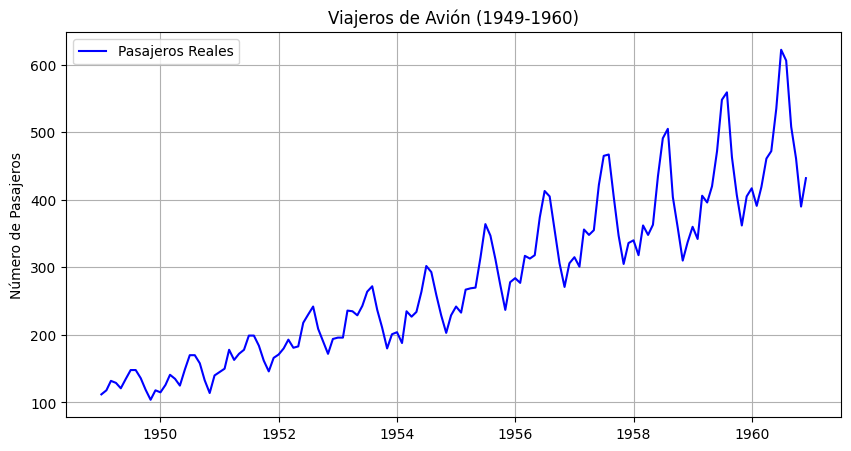

In [2]:
# 2. Graficamos los datos
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Pasajeros Reales', color='blue')
plt.title('Viajeros de Avión (1949-1960)')
plt.ylabel('Número de Pasajeros')
plt.legend()
plt.grid(True)
plt.show()

Entrenando ARIMA... (El modelo sin calendario)


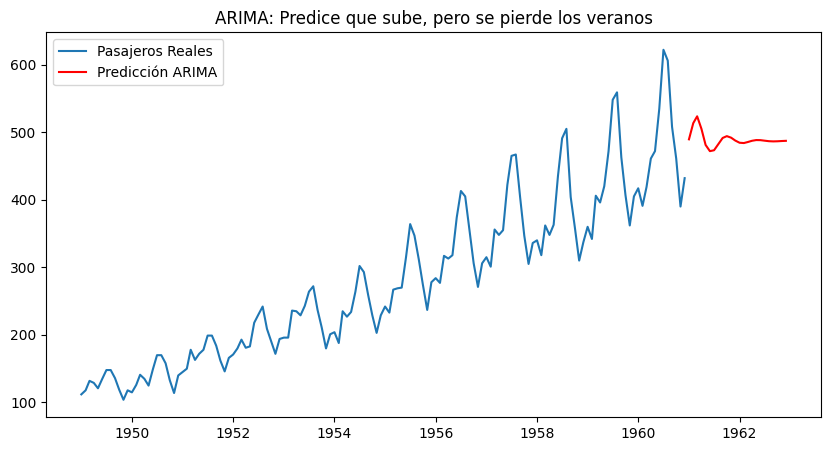

In [3]:
# 3. Entrenamos el modelo ARIMA Clásico
print("Entrenando ARIMA... (El modelo sin calendario)")
modelo_arima = ARIMA(df['Passengers'], order=(5, 1, 0)) # Botones ajustados
arima_entrenado = modelo_arima.fit()

# Le pedimos que prediga los próximos 24 meses
prediccion_arima = arima_entrenado.forecast(steps=24)

# Graficamos el desastre
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Pasajeros Reales')
plt.plot(prediccion_arima.index, prediccion_arima, color='red', label='Predicción ARIMA')
plt.title('ARIMA: Predice que sube, pero se pierde los veranos')
plt.legend()
plt.show()

Entrenando SARIMA... (El modelo que entiende las estaciones)


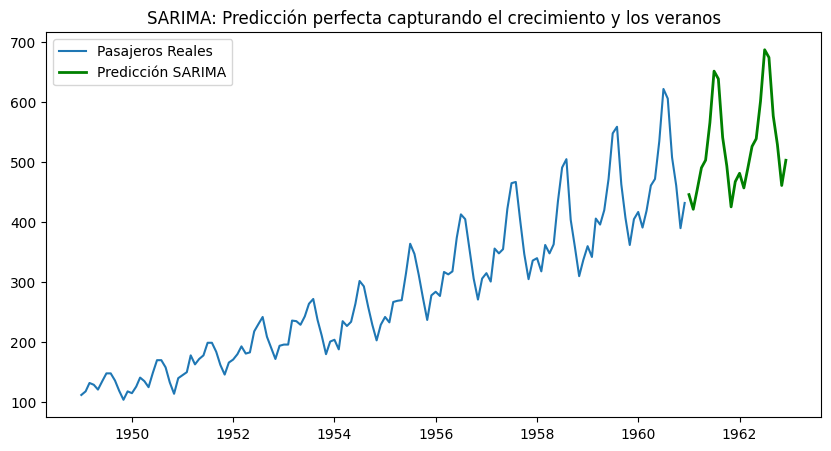

In [4]:
# 4. Entrenamos el modelo SARIMA (Con calendario)
print("Entrenando SARIMA... (El modelo que entiende las estaciones)")
# order son los botones normales, seasonal_order son los botones del calendario (el 12 significa 'anual')
modelo_sarima = SARIMAX(df['Passengers'], order=(2, 1, 1), seasonal_order=(0, 1, 1, 12))
sarima_entrenado = modelo_sarima.fit()

# Le pedimos que prediga los próximos 24 meses
prediccion_sarima = sarima_entrenado.forecast(steps=24)

# Graficamos la magia
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Pasajeros Reales')
plt.plot(prediccion_sarima.index, prediccion_sarima, color='green', label='Predicción SARIMA', linewidth=2)
plt.title('SARIMA: Predicción perfecta capturando el crecimiento y los veranos')
plt.legend()
plt.show()